# Stage 1 — Exploratory Data Analysis

**Goal:** before touching any model, understand what's actually in this data — its
shape, its quirks, and which features *look* related to churn. Everything we decide
in Stage 2 (cleaning) and Stage 4 (modeling) should trace back to something we
notice here.

We'll go through:
1. Load & first look (`shape`, `info`, `describe`)
2. The `TotalCharges` gotcha
3. Target balance (how imbalanced is churn, really?)
4. Churn vs. tenure
5. Churn vs. contract type
6. Churn vs. monthly charges
7. Churn vs. internet service
8. Correlation heatmap for the numeric features
9. Summary of hypotheses going into Stage 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(7043, 21)

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Reading `info()`:** 7,043 rows, 21 columns, and — notice — `df.info()` reports
`TotalCharges` as **non-null** with dtype `object` (text), even though we already
know from the README this column hides blank strings. `info()` only tells you a cell
isn't literally empty (`NaN`); it says nothing about a cell holding `" "` (a space)
instead of a number. That's the trap: a column can pass the null-check and still be
unusable as numeric data. We'll catch it properly in the next section.

Also worth noting: `SeniorCitizen` is `int64` (0/1) while every other yes/no field
(`Partner`, `Dependents`, ...) is stored as the strings `"Yes"`/`"No"` — an
inconsistency we'll normalize in Stage 2.

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. The `TotalCharges` gotcha

`describe(include="all")` treats `TotalCharges` as a categorical column (it lists
`unique`/`top`/`freq` instead of `mean`/`std`) — further proof it's stored as text,
not numbers. Let's force the conversion and see what breaks.

In [5]:
# errors="coerce" turns anything unparseable into NaN instead of raising
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_broken = total_charges_numeric.isna().sum()
print(f"Rows where TotalCharges failed to parse as a number: {n_broken}")

broken_rows = df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
broken_rows

Rows where TotalCharges failed to parse as a number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Finding:** every broken row has `tenure == 0` — these are brand-new customers who
haven't been billed yet, so `TotalCharges` is blank (not missing data, just "$0 so
far, no invoice exists"). None of them have churned. This tells us the right fix in
Stage 2 isn't "impute with the mean" (that would invent a number with no meaning) —
it's either `TotalCharges = 0` for these rows, or dropping them, since `tenure`
already carries the same information (0 months in either case). We'll decide with
the modeling goal in mind when we get there.

## 3. Target balance

How skewed is `Churn`? This decides everything downstream — metric choice
(Stage 5) and whether we need class-imbalance handling at all (Stage 3).

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: str


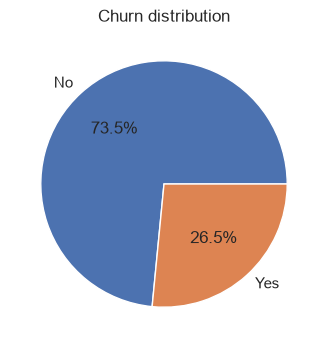

In [6]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print()
print(churn_pct.round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"])
ax.set_title("Churn distribution")
plt.show()

**Reading this:** roughly 73% No / 27% Yes. This confirms the imbalance called out in
the README — a model that always predicts "No" would score ~73% accuracy while being
useless for retention. This is why Stage 5 will lean on recall/F1/ROC-AUC instead of
accuracy, and why Stage 3 will weigh `class_weight` vs. SMOTE.

## 4. Churn vs. tenure

`tenure` is months as a customer. Hypothesis: newer customers churn more (they
haven't committed yet / haven't seen the value).

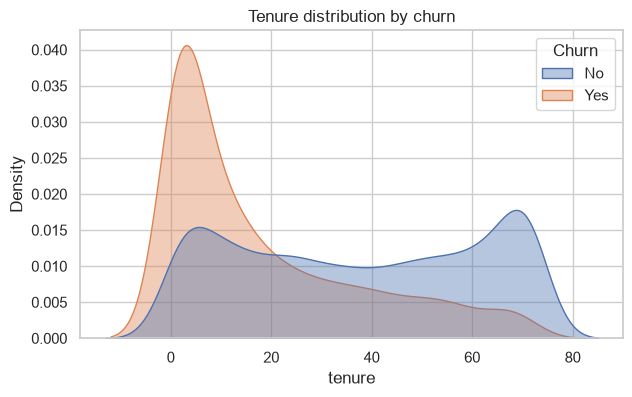

,mean,50%,min,max
Churn,,,,
No,37.569965,38.0,0.0,72.0
Yes,17.979133,10.0,1.0,72.0


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, common_norm=False, alpha=0.4, ax=ax)
ax.set_title("Tenure distribution by churn")
plt.show()

df.groupby("Churn")["tenure"].describe()[["mean", "50%", "min", "max"]]

## 5. Churn vs. contract type

Hypothesis: month-to-month customers churn far more than customers locked into
1- or 2-year contracts, since there's no penalty for leaving.

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str


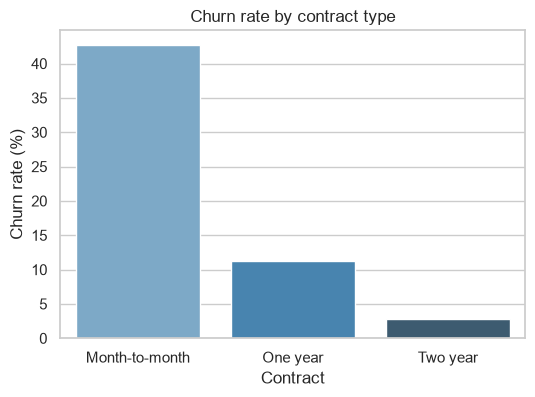

In [8]:
churn_rate_by_contract = (
    df.groupby("Contract")["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)
print(churn_rate_by_contract.round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=churn_rate_by_contract.index, y=churn_rate_by_contract.values,
            hue=churn_rate_by_contract.index, legend=False, palette="Blues_d", ax=ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by contract type")
plt.show()

## 6. Churn vs. monthly charges

Hypothesis: customers paying more per month churn more (price sensitivity /
perceived value).

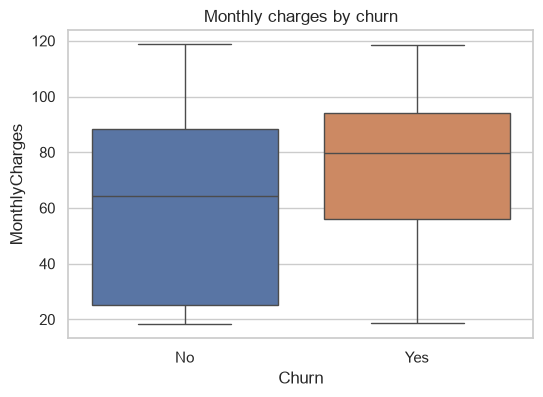

,mean,50%
Churn,,
No,61.265124,64.425
Yes,74.441332,79.650


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", legend=False,
            palette=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Monthly charges by churn")
plt.show()

df.groupby("Churn")["MonthlyCharges"].describe()[["mean", "50%"]]

## 7. Churn vs. internet service

Hypothesis: fiber-optic customers churn more than DSL — often a sign of a pricier
or less reliable product experience.

InternetService
Fiber optic    41.9%
DSL            19.0%
No              7.4%
Name: Churn, dtype: str


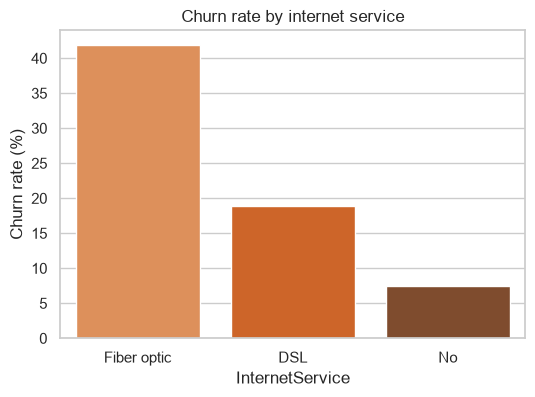

In [10]:
churn_rate_by_internet = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)
print(churn_rate_by_internet.round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=churn_rate_by_internet.index, y=churn_rate_by_internet.values,
            hue=churn_rate_by_internet.index, legend=False, palette="Oranges_d", ax=ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by internet service")
plt.show()

## 8. Correlation heatmap (numeric features)

Correlation only works on numbers, so we temporarily convert `TotalCharges` and
`Churn` to numeric just for this view (this doesn't touch `df` itself — that
conversion happens for real in Stage 2).

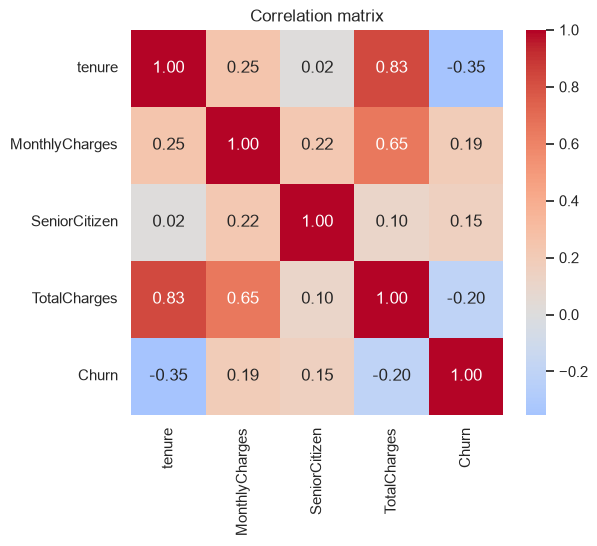

In [11]:
numeric_view = df[["tenure", "MonthlyCharges", "SeniorCitizen"]].copy()
numeric_view["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
numeric_view["Churn"] = (df["Churn"] == "Yes").astype(int)

corr = numeric_view.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.show()

## 9. Summary — hypotheses going into Stage 2

- **`tenure`** correlates negatively with churn — newer customers leave more. Keep
  as-is; it's one of our strongest signals.
- **`MonthlyCharges`** correlates positively with churn — pricier plans churn more.
- **`TotalCharges`** correlates negatively with churn, but that's largely because
  it's downstream of `tenure` (longer tenure → more accumulated charges) — the two
  are highly collinear. We'll keep this in mind for feature selection/regularization
  in Stage 4 rather than treating them as independent signals.
- **`SeniorCitizen`** has a much weaker correlation with churn than the categorical
  patterns above — a reminder that a single correlation number can undersell a
  categorical feature; `Contract` and `InternetService` mattered far more in their
  group-wise churn rates than this heatmap (which excludes them) suggests.
- **`Contract`** is the single strongest pattern we've seen: month-to-month churns
  dramatically more than one/two-year contracts — expect this to be a top feature
  in every model we train.
- **`InternetService`**: fiber-optic customers churn more than DSL — worth carrying
  into Stage 2 as a one-hot feature, and worth revisiting with SHAP in Stage 6 to
  see if it's really about the service or a confound (e.g. fiber customers also
  tend to be on month-to-month plans).

**Next up — Stage 2:** clean `TotalCharges`, normalize the Yes/No and 0/1
inconsistency, one-hot encode the categoricals, and engineer a `tenure_group`
bucket feature.